In [2]:
#Importation des librairies

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Préparation de données 

On ouvre les deux jeux de données représentant respectivement les deux éléctions 

In [3]:
#Résultats européennes et legislatives

eur24 = pd.read_csv("res_europeennes_24.csv",sep=";",encoding="ISO-8859-1")

eur24 = eur24.rename(columns = {"ï»¿id_bv":"id_bv"})

eur24 = eur24.set_index('id_bv',drop='TruCe')


eur24.head(10)

,nb_procu,nb_inscr,nb_abscent,taux_ab,nb_emarg,nb_votant,nb_blanc_null,nb_exprim,NB_ExtGauche,NB_Gauche,NB_Centre,NB_Droite,NB_ExtDroite,NB_Divers,eur_pol_dominant
id_bv,,,,,,,,,,,,,,,
01_01,37,1099,456,0.4149,643,643,4,639,0,157,144,72,114,14,Gauche
01_02,59,1232,537,0.4359,695,695,9,686,1,157,193,54,100,10,Centre
01_03,56,1225,468,0.3820,756,757,9,748,1,188,177,58,125,19,Gauche
01_04,48,1310,569,0.4344,741,741,9,732,3,211,146,51,124,21,Gauche
01_05,48,1090,444,0.4073,647,646,2,644,1,164,149,44,108,5,Gauche
01_06,58,1281,490,0.3825,791,791,7,784,2,186,159,92,138,16,Gauche
01_07,53,1127,397,0.3523,730,730,9,721,3,142,192,89,127,10,Centre
01_08,28,1000,439,0.4390,561,561,6,555,0,85,159,97,104,14,Centre
01_09,40,962,379,0.3940,583,583,3,580,0,75,175,109,117,13,Centre


In [4]:
eur24.columns

Index(['nb_procu', 'nb_inscr', 'nb_abscent', 'taux_ab', 'nb_emarg',
       'nb_votant', 'nb_blanc_null', 'nb_exprim', 'NB_ExtGauche', 'NB_Gauche',
       'NB_Centre', 'NB_Droite', 'NB_ExtDroite', 'NB_Divers',
       'eur_pol_dominant'],
      dtype='object')

In [5]:
leg24 = pd.read_csv("res_legislatives_24.csv",sep=";",encoding="ISO-8859-1")

leg24 = leg24.rename(columns = {"ï»¿id_bv":"id_bv"})

leg24 = leg24.set_index('id_bv',drop='True')


leg24.head(10)

,num_circo,nb_procu,nb_inscr,nb_emarg,nb_votant,nb_bl,nb_nul,nb_exprim,NB_ExtGauche,NB_Gauche,NB_Centre,NB_Droite,NB_ExtDroite,NB_Divers
id_bv,,,,,,,,,,,,,,
01_01,1,129,1080,781,781,7,1,773,3,279,324,70,96,1
01_02,1,137,1211,904,904,5,4,895,0,312,414,73,91,5
01_03,1,140,1211,874,874,3,5,866,8,315,346,65,130,2
01_04,1,133,1295,912,912,7,5,900,18,416,315,45,106,0
01_05,1,145,1077,823,823,3,2,818,1,320,356,56,82,3
01_06,1,147,1267,921,922,14,2,906,5,334,364,63,135,5
01_07,1,131,1109,822,822,11,5,806,2,257,376,75,96,0
01_08,1,97,973,688,688,12,4,672,2,171,311,86,99,3
01_09,1,99,934,672,672,3,5,664,3,145,327,77,111,1


In [6]:
leg24.columns

Index(['num_circo', 'nb_procu', 'nb_inscr', 'nb_emarg', 'nb_votant', 'nb_bl',
       'nb_nul', 'nb_exprim', 'NB_ExtGauche', 'NB_Gauche', 'NB_Centre',
       'NB_Droite', 'NB_ExtDroite', 'NB_Divers'],
      dtype='object')

# 1 - Résultats des gauches 

On analyse les résultats de la gauches ainsi leurs évolutions lors des deux évolutions


### 1-1 Ecart des voix 

In [7]:
#Récupération des voix de gauche 


gauche_eur = eur24[['NB_ExtGauche', 'NB_Gauche']]

gauche_eur.head(5)

,NB_ExtGauche,NB_Gauche
id_bv,,
01_01,0,157
01_02,1,157
01_03,1,188
01_04,3,211
01_05,1,164


In [8]:
# Résultats des législtaives

gauche_leg = leg24[['NB_ExtGauche', 'NB_Gauche']]

gauche_leg.head(5)

,NB_ExtGauche,NB_Gauche
id_bv,,
01_01,3,279
01_02,0,312
01_03,8,315
01_04,18,416
01_05,1,320


In [9]:
#Additionner les voix de gauches pour ces deux élections

total_gauche_eur = np.sum(gauche_eur['NB_ExtGauche'])+ np.sum(gauche_eur['NB_Gauche'])

total_gauche_leg = np.sum(gauche_leg['NB_ExtGauche'])+ np.sum(gauche_leg['NB_Gauche'])

voix_gauche = [total_gauche_eur,total_gauche_leg]

voix_gauche = pd.DataFrame(voix_gauche).T

voix_gauche = voix_gauche.rename(columns = {0:'européennes',1:'législative'},index={0:"nb voix"})

In [10]:
voix_gauche

,européennes,législative
nb voix,242943,458156


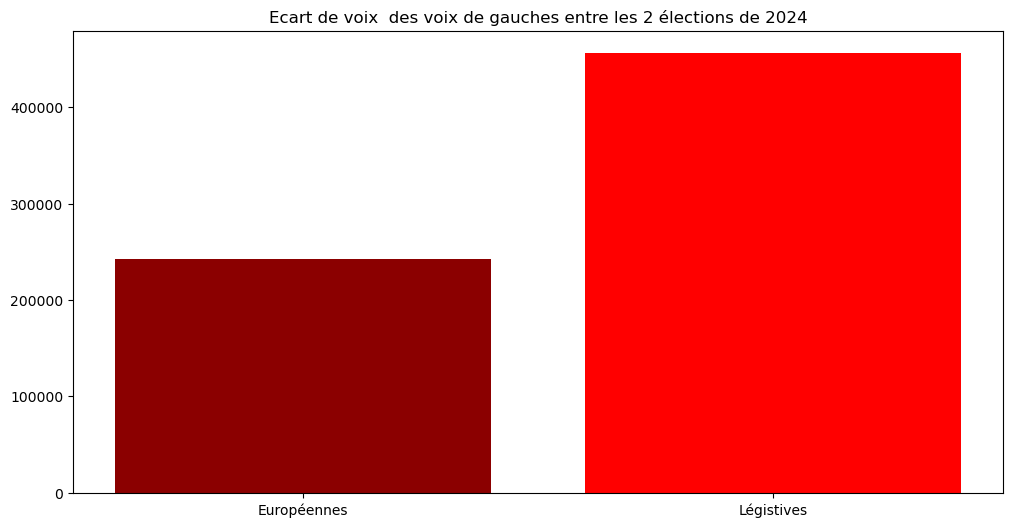

In [11]:
plt.figure(figsize=(12,6))

names = ['Européennes','Légistives']

values = [242943,456667]


plt.bar(names,values,color = ['darkred','red']) 
plt.title("Ecart de voix  des voix de gauches entre les 2 élections de 2024")

plt.savefig("ecart_voix_gauche.png")

plt.show()

### 1-2 - Analyse par bureau de vote 


Nous allons analyser les différents résultats des voix de gauches en fonction des bureaux de vote 

In [12]:
#Ouverture des jeux de données des résultats des voix de gauche 

gauche = pd.read_csv("res_gauche.csv",sep=";",encoding="ISO-8859-1")

gauche = gauche.rename(columns = {"ï»¿id_bv":"id_bv"})

gauche = gauche.set_index('id_bv',drop="True")

gauche.head(10)

,total_G_EUR,total_G_LEG,ecart_voix_G,p_G_EUR,p_G_LEG,nb_PS,nb_EELV,nb_PCF,nb_LFI,autresGauche,ExtGauche,partie_dominant
id_bv,,,,,,,,,,,,
01_01,295,282,-13,"0,4617","0,3648",136,66,4,84,3,2,Partie Socialiste
01_02,329,312,-17,"0,4796","0,3486",171,72,5,71,9,1,Partie Socialiste
01_03,369,323,-46,"0,4933","0,3730",178,86,11,86,5,3,Partie Socialiste
01_04,390,434,44,"0,5328","0,4822",175,66,15,125,5,4,Partie Socialiste
01_05,338,321,-17,"0,5248","0,3924",173,79,5,75,5,1,Partie Socialiste
01_06,379,339,-40,"0,4834","0,3742",189,88,8,87,3,4,Partie Socialiste
01_07,303,259,-44,"0,4202","0,3213",156,60,8,70,4,5,Partie Socialiste
01_08,181,173,-8,"0,3261","0,2574",96,47,3,34,1,0,Partie Socialiste
01_09,166,148,-18,"0,2862","0,2229",91,28,2,43,2,0,Partie Socialiste


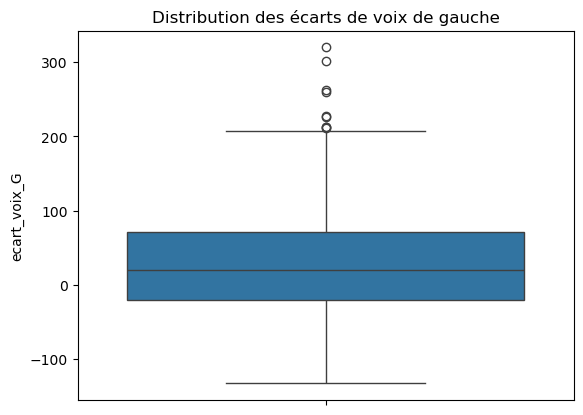

In [13]:
#Distribution des écart de voix de gauches 

sns.boxplot(gauche["ecart_voix_G"])

plt.title("Distribution des écarts de voix de gauche")

plt.savefig("boxplot_v_gauche.png")

plt.show()

#### distribution des écart par partie

On a remarquer qu'on a deux parties de gauche qui s'imposes dans les résultats 

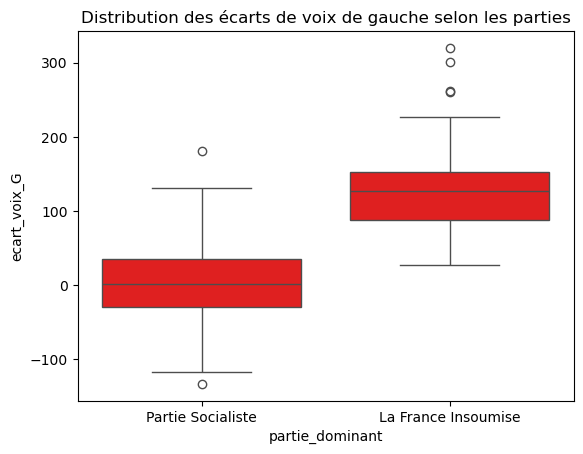

In [14]:
sns.boxplot(x = gauche["partie_dominant"],y=gauche["ecart_voix_G"],data=gauche,color="red")

plt.title("Distribution des écarts de voix de gauche selon les parties")

plt.savefig("boxplot_v_gauche_partie.png")

plt.show()

On a une écart évidente entre ces deux parties lors des écarts de voix de gauches .... on a une meilleur mobilisation de voix dans les bureau de votes dominée par La France Insoumise 

### 1-3 Parties de gauches 

Pour analyser les différentes parties politiques , on utilisera seulement les voix des éléctions européennes de 2024 pour cause qu'il n'y a pas de sur/sous-représenttaion des votes ainsi des alliance politiques 

In [15]:
partie_gauche = [np.sum(gauche['ExtGauche']),
                 np.sum(gauche["nb_LFI"]),
                 np.sum(gauche["nb_PCF"]),
                 np.sum(gauche["nb_EELV"]),
                 np.sum(gauche["nb_PS"]),
                 np.sum(gauche["autresGauche"])]

partie_gauche

[3646, 136412, 11304, 87169, 186139, 5665]

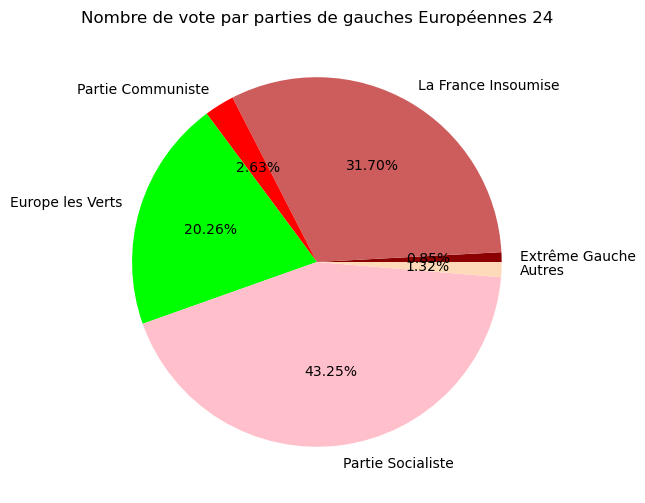

In [16]:
#Diagramme circulaire
plt.figure(figsize=(10,6))

plt.pie(partie_gauche,labels = ["Extrême Gauche",
                                 "La France Insoumise",
                                 "Partie Communiste",
                                 "Europe les Verts",
                                 "Partie Socialiste",
                                 "Autres"], colors = ['darkred','indianred','red','lime','pink','peachpuff'], autopct = '%.2f%%')

plt.title('Nombre de vote par parties de gauches Européennes 24')
plt.savefig("eur24_res_gauches_P.png")

plt.show()

In [17]:
#dominantion par bureau de vote

nb_part = gauche["partie_dominant"].value_counts()

nb_part

partie_dominant
Partie Socialiste      701
La France Insoumise    200
Name: count, dtype: int64

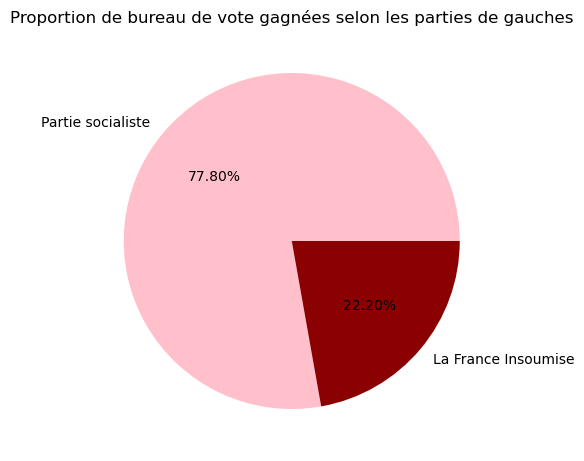

In [18]:
#Nombre de bureau de vote par parties
nb_part = [701,200]

# Représentation grahiques 


plt.figure(figsize=(10,12))
plt.pie(nb_part,labels = ["Partie socialiste","La France Insoumise"], colors = ['pink','darkred'], autopct = '%.2f%%')
plt.title('Proportion de bureau de vote gagnées selon les parties de gauches')

plt.savefig("pie_P_Gauche.png")


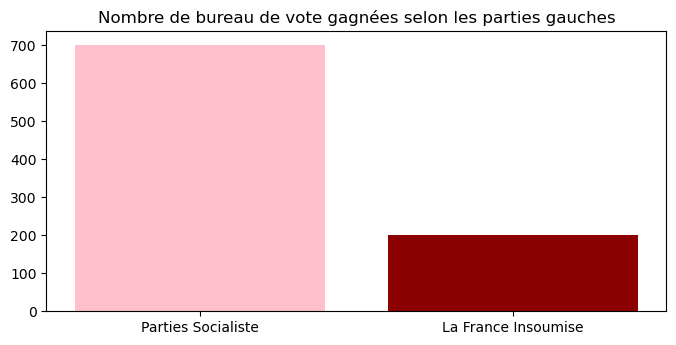

In [19]:

plt.figure(figsize=(8,8))
plt.bar(["Parties Socialiste","La France Insoumise"],nb_part,color = ['pink','darkred']) 
plt.title("Nombre de bureau de vote gagnées selon les parties gauches")

plt.savefig("bar_P_gauche.png")

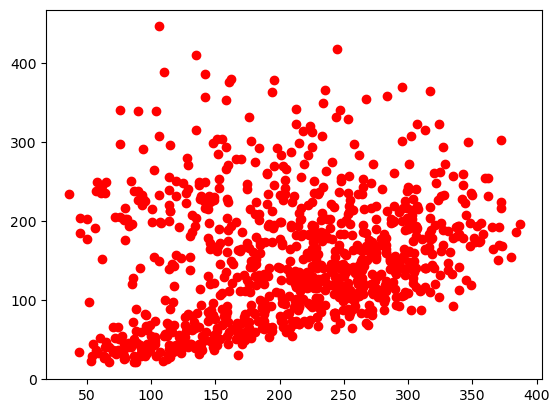

In [20]:
#Représentation graphiques 

plt.plot(gauche["nb_PS"],gauche["nb_LFI"],'or') 

plt.show()

In [66]:
np.corrcoef(gauche["nb_PS"],gauche["nb_LFI"])

array([[1.       , 0.2687853],
       [0.2687853, 1.       ]])

Avec ce nuage de point initiales on peut pas exprimer une liaison entre les différentes votes des deux parties. 

L'idée maintenant est de voire les écart absolue des nombre de voix entres les deux parties de la  gauche 

#### 2-2 Ecart de voix entre les deux parties 


On utilisera les voix des deux parties lors des élections européenes de 2024 



In [21]:
gauche["rap_LFI_PS"] = np.round(gauche["nb_LFI"]/gauche["nb_PS"],2)


rap_LFI_PS = pd.DataFrame(gauche["rap_LFI_PS"])

In [22]:
rap_LFI_PS

,rap_LFI_PS
id_bv,
01_01,0.62
01_02,0.42
01_03,0.48
01_04,0.71
01_05,0.43
...,...
20_72,1.93
20_73,1.05
20_74,1.15


il y a pas le lien entre le rapport des voix des parties LFI et le PS, et le taux d'abstention par bureau de vote


<Axes: >

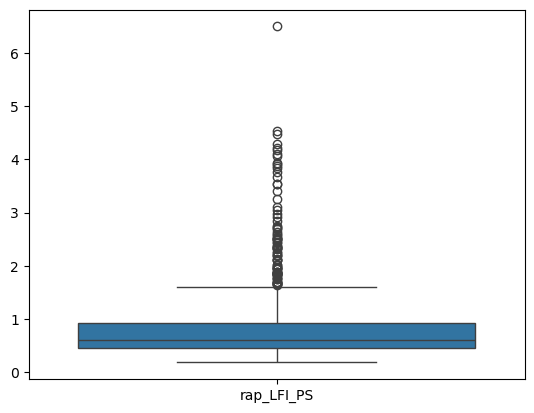

In [23]:
sns.boxplot(rap_LFI_PS)

# 2 - Résultats des droites 



On va analyser les éléctorat des parties de droites lors des deux éléctions sur Paris 



In [40]:
#ouverture des fichiers 

droite = pd.read_csv("res_droite.csv",sep=";",encoding="ISO-8859-1")

droite = droite.rename(columns={"ï»¿id_bv":"id_bv"})

droite = droite.set_index('id_bv',drop="True")

droite.head(5)



,v_D_EUR,p_D_EUR,v_D_LEG,p_D_EUR .1,ecart_D,nb_LR,nb_RN,nb_Rec,nb_autreDroite,nb_extDroite,partie_dominant
id_bv,,,,,,,,,,,
01_01,188,"0,2942",166,"0,2147",-22,72,60,42,2,12,Les RÃ©publicains
01_02,154,"0,2245",164,"0,1832",10,54,54,37,2,7,Les RÃ©publicains
01_03,183,"0,2447",195,"0,2252",12,58,71,37,0,17,Rassemblement National
01_04,175,"0,2391",151,"0,1678",-24,51,69,34,1,20,Rassemblement National
01_05,153,"0,2376",138,"0,1687",-15,44,53,41,3,12,Rassemblement National


In [41]:
#Récupération des voix de gauche 


droite_eur = eur24[['NB_Droite', 'NB_ExtDroite']]

droite_eur.head(5)

,NB_Droite,NB_ExtDroite
id_bv,,
01_01,72,114
01_02,54,100
01_03,58,125
01_04,51,124
01_05,44,108


In [42]:
#Additionner les voix de gauches pour ces deux élections

total_droite_eur = np.sum(droite['v_D_EUR'])

total_droite_leg = np.sum(droite['v_D_LEG'])

voix_droite = [total_droite_eur,total_droite_leg]

voix_droite = pd.DataFrame(voix_droite).T

voix_droite = voix_droite.rename(columns = {0:'européennes',1:'législative'},index={0:"nb voix"})

voix_droite

,européennes,législative
nb voix,217768,201523


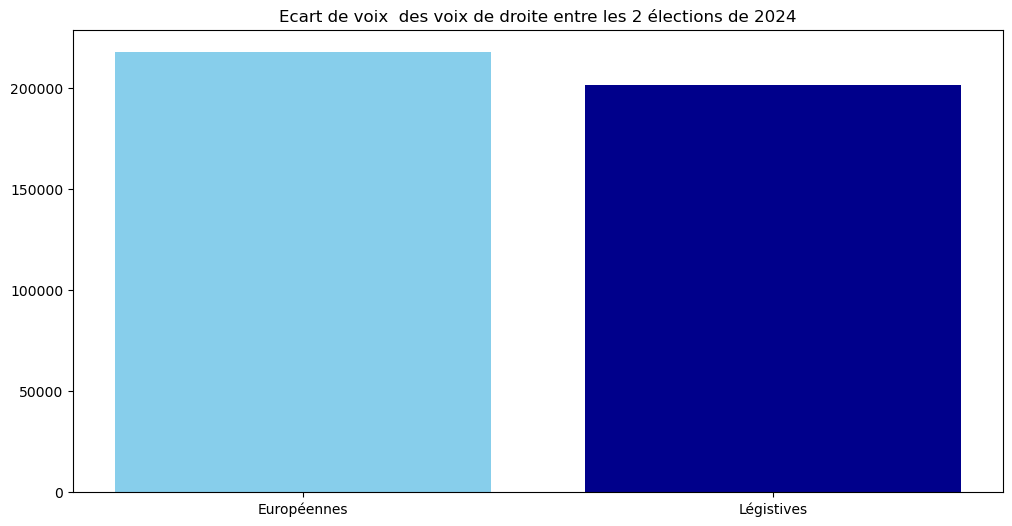

In [43]:
plt.figure(figsize=(12,6))

names = ['Européennes','Légistives']

values = [217768,201523]


plt.bar(names,values,color = ['skyblue','darkblue']) 
plt.title("Ecart de voix  des voix de droite entre les 2 élections de 2024")

plt.savefig("ecart_voix_droite.png")

plt.show()

### 2-2 Analyse par bureau de vote

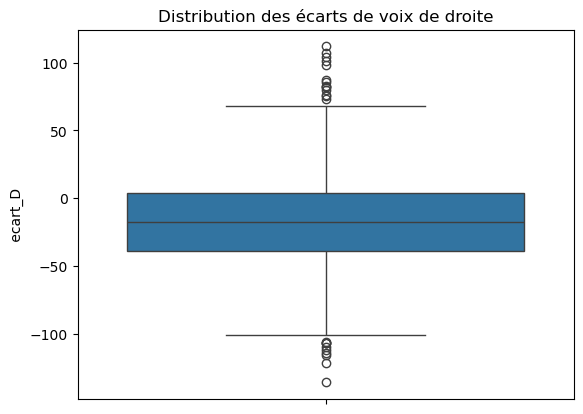

In [48]:
#Distribution des écart de voix de gauches 

sns.boxplot(droite[" ecart_D "])

plt.title("Distribution des écarts de voix de droite")

plt.savefig("boxplot_v_droite.png")

plt.show()

In [46]:
droite.columns

Index(['v_D_EUR', ' p_D_EUR ', 'v_D_LEG', ' p_D_EUR .1', ' ecart_D ', 'nb_LR',
       'nb_RN', 'nb_Rec', 'nb_autreDroite', 'nb_extDroite', 'partie_dominant'],
      dtype='object')

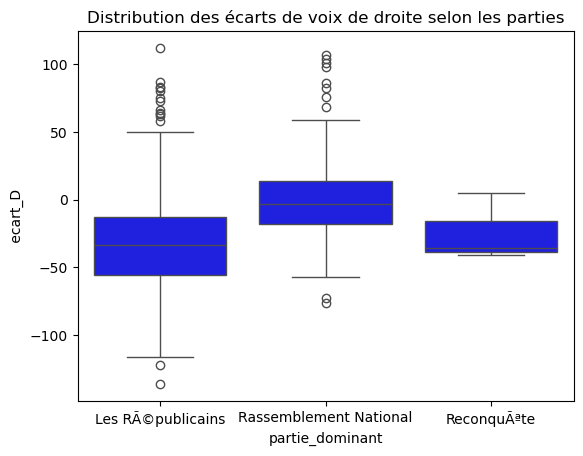

In [49]:
#Dipersion des écarts entre les Républicains et le RN

sns.boxplot(x = droite["partie_dominant"],y=droite[" ecart_D "],data=droite,color="blue")

plt.title("Distribution des écarts de voix de droite selon les parties")

plt.savefig("boxplot_v_droite_partie.png")

plt.show()

On remarque une diminution des votes de droites dans les zones où les Républicains ou Reconquête dominent 

On peut dire par hypthèse que les votes des parties de la majorités présidentielles à augmentés dans ces zones 

### 2-3 Parties de droite

Pour analyser les différentes parties politiques de droite, on utilisera seulement les voix des éléctions européennes de 2024 pour cause qu'il n'y a pas de sur/sous-représenttaion des votes ainsi des alliance politiques

In [51]:
partie_droite = [np.sum(droite['nb_LR']),
                 np.sum(droite["nb_RN"]),
                 np.sum(droite["nb_Rec"]),
                 np.sum(droite["nb_extDroite"]),
                 np.sum(droite["nb_autreDroite"])]

partie_droite

[85456, 69545, 48286, 11371, 3110]

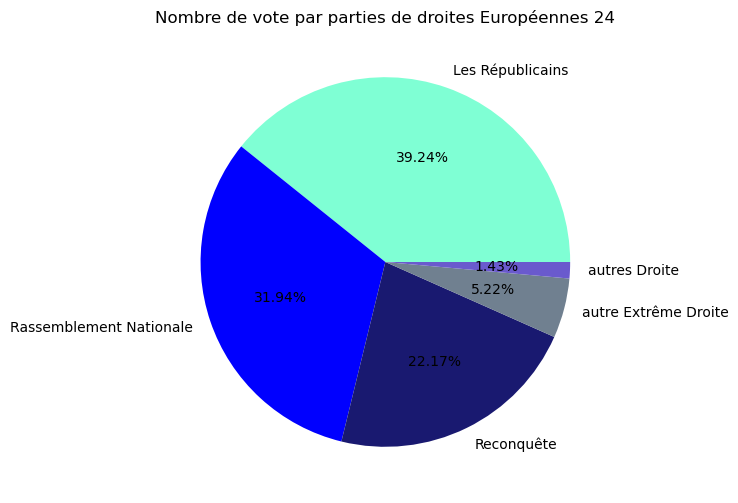

In [53]:
#Diagramme circulaire
plt.figure(figsize=(10,6))

plt.pie(partie_droite,labels = ["Les Républicains",
                                 "Rassemblement Nationale",
                                 "Reconquête",
                                 "autre Extrême Droite",
                                 "autres Droite"], colors = ['aquamarine','blue','midnightblue','slategrey','slateblue'], autopct = '%.2f%%')

plt.title('Nombre de vote par parties de droites Européennes 24')
plt.savefig("eur24_res_droite_P.png")

plt.show()

### 2-4 Rapport entre parties 

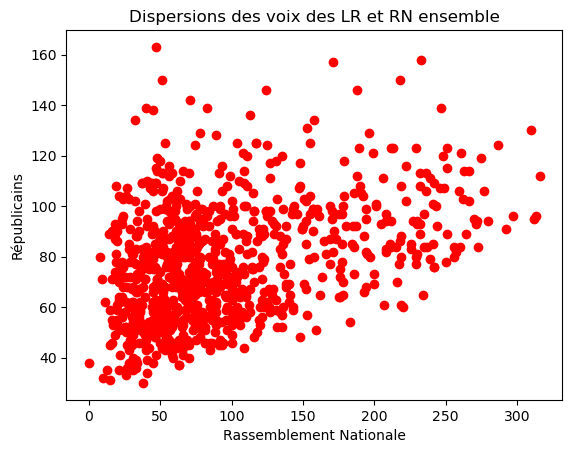

In [59]:
#Représentation graphiques 

plt.plot(droite["nb_LR"],droite["nb_RN"],'or') 
plt.title("Dispersions des voix des LR et RN ensemble")

plt.ylabel("Républicains")
plt.xlabel("Rassemblement Nationale")

plt.savefig("dis_voix_droite.png")
plt.show()

In [67]:
np.corrcoef(droite["nb_LR"],droite["nb_RN"])

array([[1.        , 0.39351242],
       [0.39351242, 1.        ]])